In [65]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random
import numpy as np
from torch.utils.data import Dataset, DataLoader


In [141]:
torch.manual_seed(0)
random.seed(0)

vocab_size = 3
seq_len = 3
hidden_size = 40
num_epochs = 1000

def generate_sample():
    tokens = [random.randint(1, vocab_size) for _ in range(seq_len)]
    x = F.one_hot(torch.tensor(tokens), num_classes=vocab_size+1).float().unsqueeze(0)
    y = torch.tensor(tokens).unsqueeze(0)
    return x, y

class RNN_AE(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = nn.RNN(vocab_size+1, hidden_size, batch_first=True)
        self.decoder = nn.RNN(vocab_size+1, hidden_size, batch_first=True)
        self.out = nn.Linear(hidden_size, vocab_size+1)

    def forward(self, x):
        _, h = self.encoder(x)
        dec_input = torch.zeros((1, 1, vocab_size+1))
        outputs = []
        for _ in range(seq_len):
            dec_out, h = self.decoder(dec_input, h)
            logits = self.out(dec_out)
            outputs.append(logits)
            dec_input = logits.detach()
        return torch.cat(outputs, dim=1)

model = RNN_AE()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

for epoch in range(num_epochs):
    x, y = generate_sample()
    logits = model(x)
    loss = sum(criterion(logits[:, t], y[:, t]) for t in range(seq_len)) / seq_len
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    if epoch % 50 == 0:
        pred = logits.argmax(dim=2)
        print(f"Epoch {epoch}: Loss={loss.item():.4f}, Predicted={pred.tolist()}, Target={y.tolist()}")


Epoch 0: Loss=1.4586, Predicted=[[3, 3, 3]], Target=[[2, 2, 1]]
Epoch 50: Loss=0.8920, Predicted=[[2, 3, 1]], Target=[[2, 1, 1]]
Epoch 100: Loss=0.5884, Predicted=[[3, 3, 2]], Target=[[3, 1, 2]]
Epoch 150: Loss=0.4137, Predicted=[[3, 2, 2]], Target=[[3, 2, 3]]
Epoch 200: Loss=0.9580, Predicted=[[2, 2, 3]], Target=[[2, 2, 2]]
Epoch 250: Loss=0.1235, Predicted=[[3, 1, 3]], Target=[[3, 1, 3]]
Epoch 300: Loss=0.0605, Predicted=[[1, 3, 2]], Target=[[1, 3, 2]]
Epoch 350: Loss=0.0442, Predicted=[[3, 3, 1]], Target=[[3, 3, 1]]
Epoch 400: Loss=0.3944, Predicted=[[1, 1, 1]], Target=[[1, 1, 2]]
Epoch 450: Loss=0.0203, Predicted=[[2, 2, 1]], Target=[[2, 2, 1]]
Epoch 500: Loss=0.0122, Predicted=[[2, 3, 2]], Target=[[2, 3, 2]]
Epoch 550: Loss=0.0151, Predicted=[[1, 1, 3]], Target=[[1, 1, 3]]
Epoch 600: Loss=0.0023, Predicted=[[1, 2, 1]], Target=[[1, 2, 1]]
Epoch 650: Loss=0.0061, Predicted=[[1, 3, 2]], Target=[[1, 3, 2]]
Epoch 700: Loss=0.0040, Predicted=[[1, 3, 2]], Target=[[1, 3, 2]]
Epoch 750: Lo

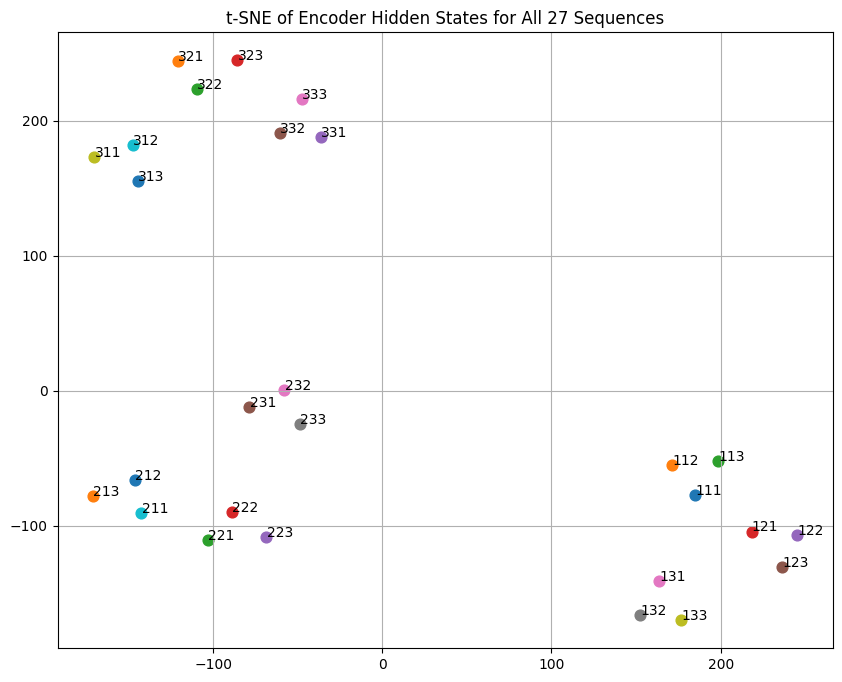

In [143]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import itertools

# Step 1: Generate all 27 sequences
sequences = list(itertools.product(range(1,4), repeat=3))

# Step 2–3: Run through encoder and collect hidden states
hidden_codes = []
labels = []
model.eval()
with torch.no_grad():
    for seq in sequences:
        x = F.one_hot(torch.tensor(seq), num_classes=4).float().unsqueeze(0)  # (1, 3, 3)
        _, h = model.encoder(x)
        hidden_codes.append(h[0,0].numpy())  # extract (H,) from (1,1,H)
        labels.append("".join(map(str, seq)))

# Step 4: Reduce dimension
hidden_codes = torch.tensor(hidden_codes)
tsne = TSNE(n_components=2, perplexity=5, random_state=42)
embeddings = tsne.fit_transform(hidden_codes)

# Step 5: Plot
plt.figure(figsize=(10, 8))
for i, txt in enumerate(labels):
    plt.scatter(embeddings[i,0], embeddings[i,1], s=60)
    plt.text(embeddings[i,0]+0.1, embeddings[i,1]+0.1, txt, fontsize=10)
plt.title("t-SNE of Encoder Hidden States for All 27 Sequences")
plt.grid(True)
plt.show()


In [144]:
class probe(nn.Module):
    def __init__(self, hidden_size, vocab_size):
        super().__init__()
        self.linear = nn.Linear(hidden_size, vocab_size+1)

    def forward(self, x):
        out = self.linear(x)
        return out

In [145]:
# tokens start from 1
class Dataset_converter(Dataset):
    def __init__(self, grammar):
        
        self.X = torch.tensor(list(grammar.keys()))
        self.y = torch.tensor(list(grammar.values()))

        self.X = self.X.long()
        self.y = self.y.long()

    def __getitem__(self, index):
        return self.X[index], self.y[index]

    def __len__(self):
        return self.X.shape[0]

In [146]:
grammar = {}
sequences = list(itertools.product(range(1,4), repeat=3))

for sequence in sequences:
    grammar[sequence] = sequence[0]*1 + sequence[1]*2 + sequence[2]*3

In [147]:
grammar

{(1, 1, 1): 6,
 (1, 1, 2): 9,
 (1, 1, 3): 12,
 (1, 2, 1): 8,
 (1, 2, 2): 11,
 (1, 2, 3): 14,
 (1, 3, 1): 10,
 (1, 3, 2): 13,
 (1, 3, 3): 16,
 (2, 1, 1): 7,
 (2, 1, 2): 10,
 (2, 1, 3): 13,
 (2, 2, 1): 9,
 (2, 2, 2): 12,
 (2, 2, 3): 15,
 (2, 3, 1): 11,
 (2, 3, 2): 14,
 (2, 3, 3): 17,
 (3, 1, 1): 8,
 (3, 1, 2): 11,
 (3, 1, 3): 14,
 (3, 2, 1): 10,
 (3, 2, 2): 13,
 (3, 2, 3): 16,
 (3, 3, 1): 12,
 (3, 3, 2): 15,
 (3, 3, 3): 18}

In [148]:
linear_probe = probe(40, 18)
data_set = Dataset_converter(grammar)
train_loader = DataLoader(data_set, batch_size=1)
optimizer = torch.optim.Adam(linear_probe.parameters(), lr=1e-1, weight_decay=1e-6)
criterion = torch.nn.CrossEntropyLoss()


for iter in range(50):
    correct = 0
    total = 0
    for x, y in train_loader:
        optimizer.zero_grad()

        with torch.no_grad():
            x = F.one_hot(torch.tensor(x), num_classes=4).float().unsqueeze(0)
            _, h = model.encoder(x[0])

        y_pred = linear_probe(h[0][0])
        loss = criterion(y_pred, y[0])     
        loss.backward()
        optimizer.step()
        
        with torch.no_grad():
            total += 1
            if y_pred.argmax() == y:
                correct += 1
    print('Iter:', iter, ' Accuracy: ', correct/total)




/var/folders/_7/jy1bxm8x25zgqldfzz7cqv8r0000gn/T/ipykernel_44007/3677471660.py:15: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x = F.one_hot(torch.tensor(x), num_classes=4).float().unsqueeze(0)


Iter: 0  Accuracy:  0.0
Iter: 1  Accuracy:  0.2962962962962963
Iter: 2  Accuracy:  0.3333333333333333
Iter: 3  Accuracy:  0.4444444444444444
Iter: 4  Accuracy:  0.5555555555555556
Iter: 5  Accuracy:  0.37037037037037035
Iter: 6  Accuracy:  0.6666666666666666
Iter: 7  Accuracy:  0.6296296296296297
Iter: 8  Accuracy:  0.6666666666666666
Iter: 9  Accuracy:  0.7777777777777778
Iter: 10  Accuracy:  0.7777777777777778
Iter: 11  Accuracy:  0.7407407407407407
Iter: 12  Accuracy:  0.7037037037037037
Iter: 13  Accuracy:  0.8148148148148148
Iter: 14  Accuracy:  0.7777777777777778
Iter: 15  Accuracy:  0.8888888888888888
Iter: 16  Accuracy:  1.0
Iter: 17  Accuracy:  1.0
Iter: 18  Accuracy:  1.0
Iter: 19  Accuracy:  1.0
Iter: 20  Accuracy:  1.0
Iter: 21  Accuracy:  1.0
Iter: 22  Accuracy:  1.0
Iter: 23  Accuracy:  1.0
Iter: 24  Accuracy:  1.0
Iter: 25  Accuracy:  1.0
Iter: 26  Accuracy:  1.0
Iter: 27  Accuracy:  1.0
Iter: 28  Accuracy:  1.0
Iter: 29  Accuracy:  1.0
Iter: 30  Accuracy:  1.0
Iter: 31 